In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.algorithms.fragment_linking.utils import compute_vector_angle,is_direction_too_similar
from neural_reconstruction.core.preprocessing import dilate_epidermis_vertically

import skimage as ski
# from skimage.measure import label
from scipy.spatial import KDTree


In [92]:
BASE_PATH = Path('/home/pony/projects/ienf_q/data_0331')
IMAGE_ID = 'S1585-2_b'

In [93]:
image      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/image.png',       cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
mask       = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/mask.png',        cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/weka.png',        cv2.IMREAD_GRAYSCALE)
label      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/label.png',       cv2.IMREAD_GRAYSCALE)


In [94]:
roi_mask = dilate_epidermis_vertically(mask, offset_px=50)
roi_image = cv2.bitwise_and(image, image, mask=roi_mask)


(1946, 5632) 255


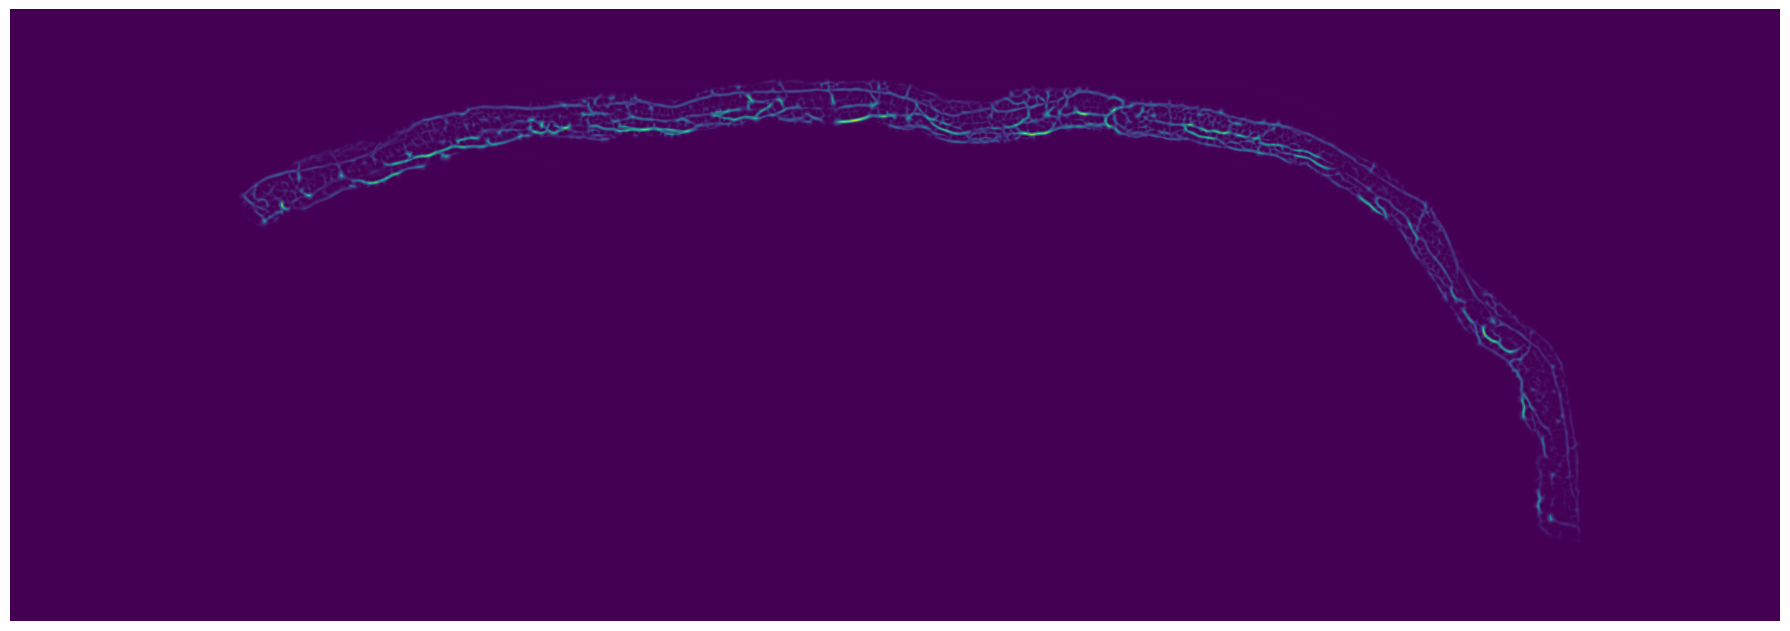

In [95]:

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
background = cv2.morphologyEx(roi_image, cv2.MORPH_OPEN, kernel)
roi_image = cv2.subtract(roi_image, background)

clahe = cv2.createCLAHE()
roi_image = clahe.apply(roi_image)

roi_image = ski.filters.sato(roi_image, sigmas=range(4, 8), black_ridges=False)
# min max roi image
roi_image = (roi_image - roi_image.min()) / (roi_image.max() - roi_image.min()) * 255
roi_image = roi_image.astype(np.uint8)

print(roi_image.shape, roi_image.max())
fig, axes = plt.subplots(1, 1, figsize=(18, 24))
axes.axis('off')
axes.imshow(roi_image)

plt.tight_layout()
plt.show()

In [96]:

roi_annotation = cv2.bitwise_and(annotation, annotation, mask=roi_mask)

# apply opening to roi_annotation to remove small noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
# roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_OPEN, kernel)

# apply closing to roi_annotation to fill small holes
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_CLOSE, kernel, iterations=3)
roi_annotation[roi_annotation > 0] = 255


gt_builder = TopologyBuilder()
roi_label = cv2.bitwise_and(label, label, mask=roi_mask)
roi_label = cv2.morphologyEx(roi_label, cv2.MORPH_CLOSE, kernel, iterations=3)
gt_graph = gt_builder.build_seed_graph(roi_label)

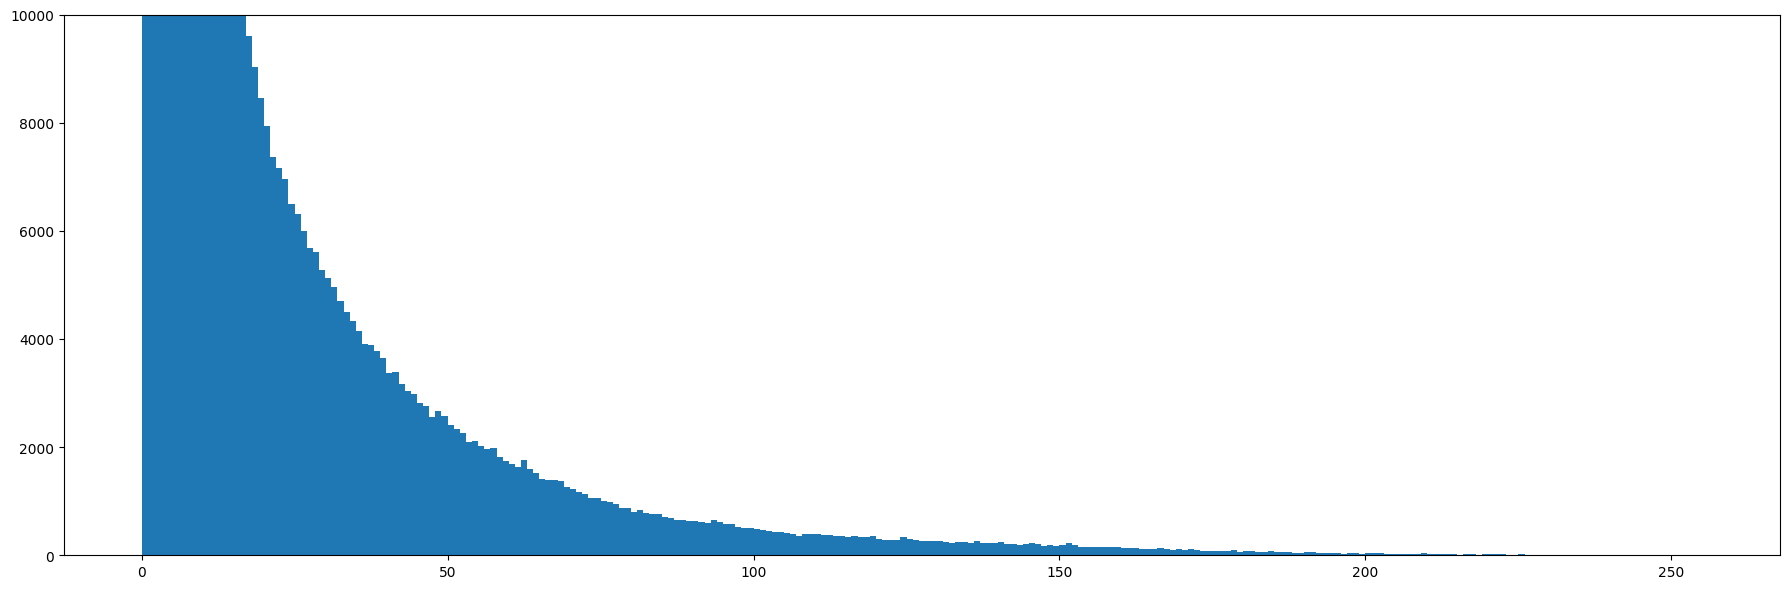

In [97]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

axes.hist(roi_image[roi_mask > 0].flatten(), bins=255)
axes.set_ylim(0, 10000)

plt.tight_layout()
plt.show()


Otsu threshold  : 46.0
Low  threshold  : 46.0

Total roi_label pixels   : 28595
Covered by final mask    : 23947
Not covered              : 4648
Pixel coverage rate      : 83.7%


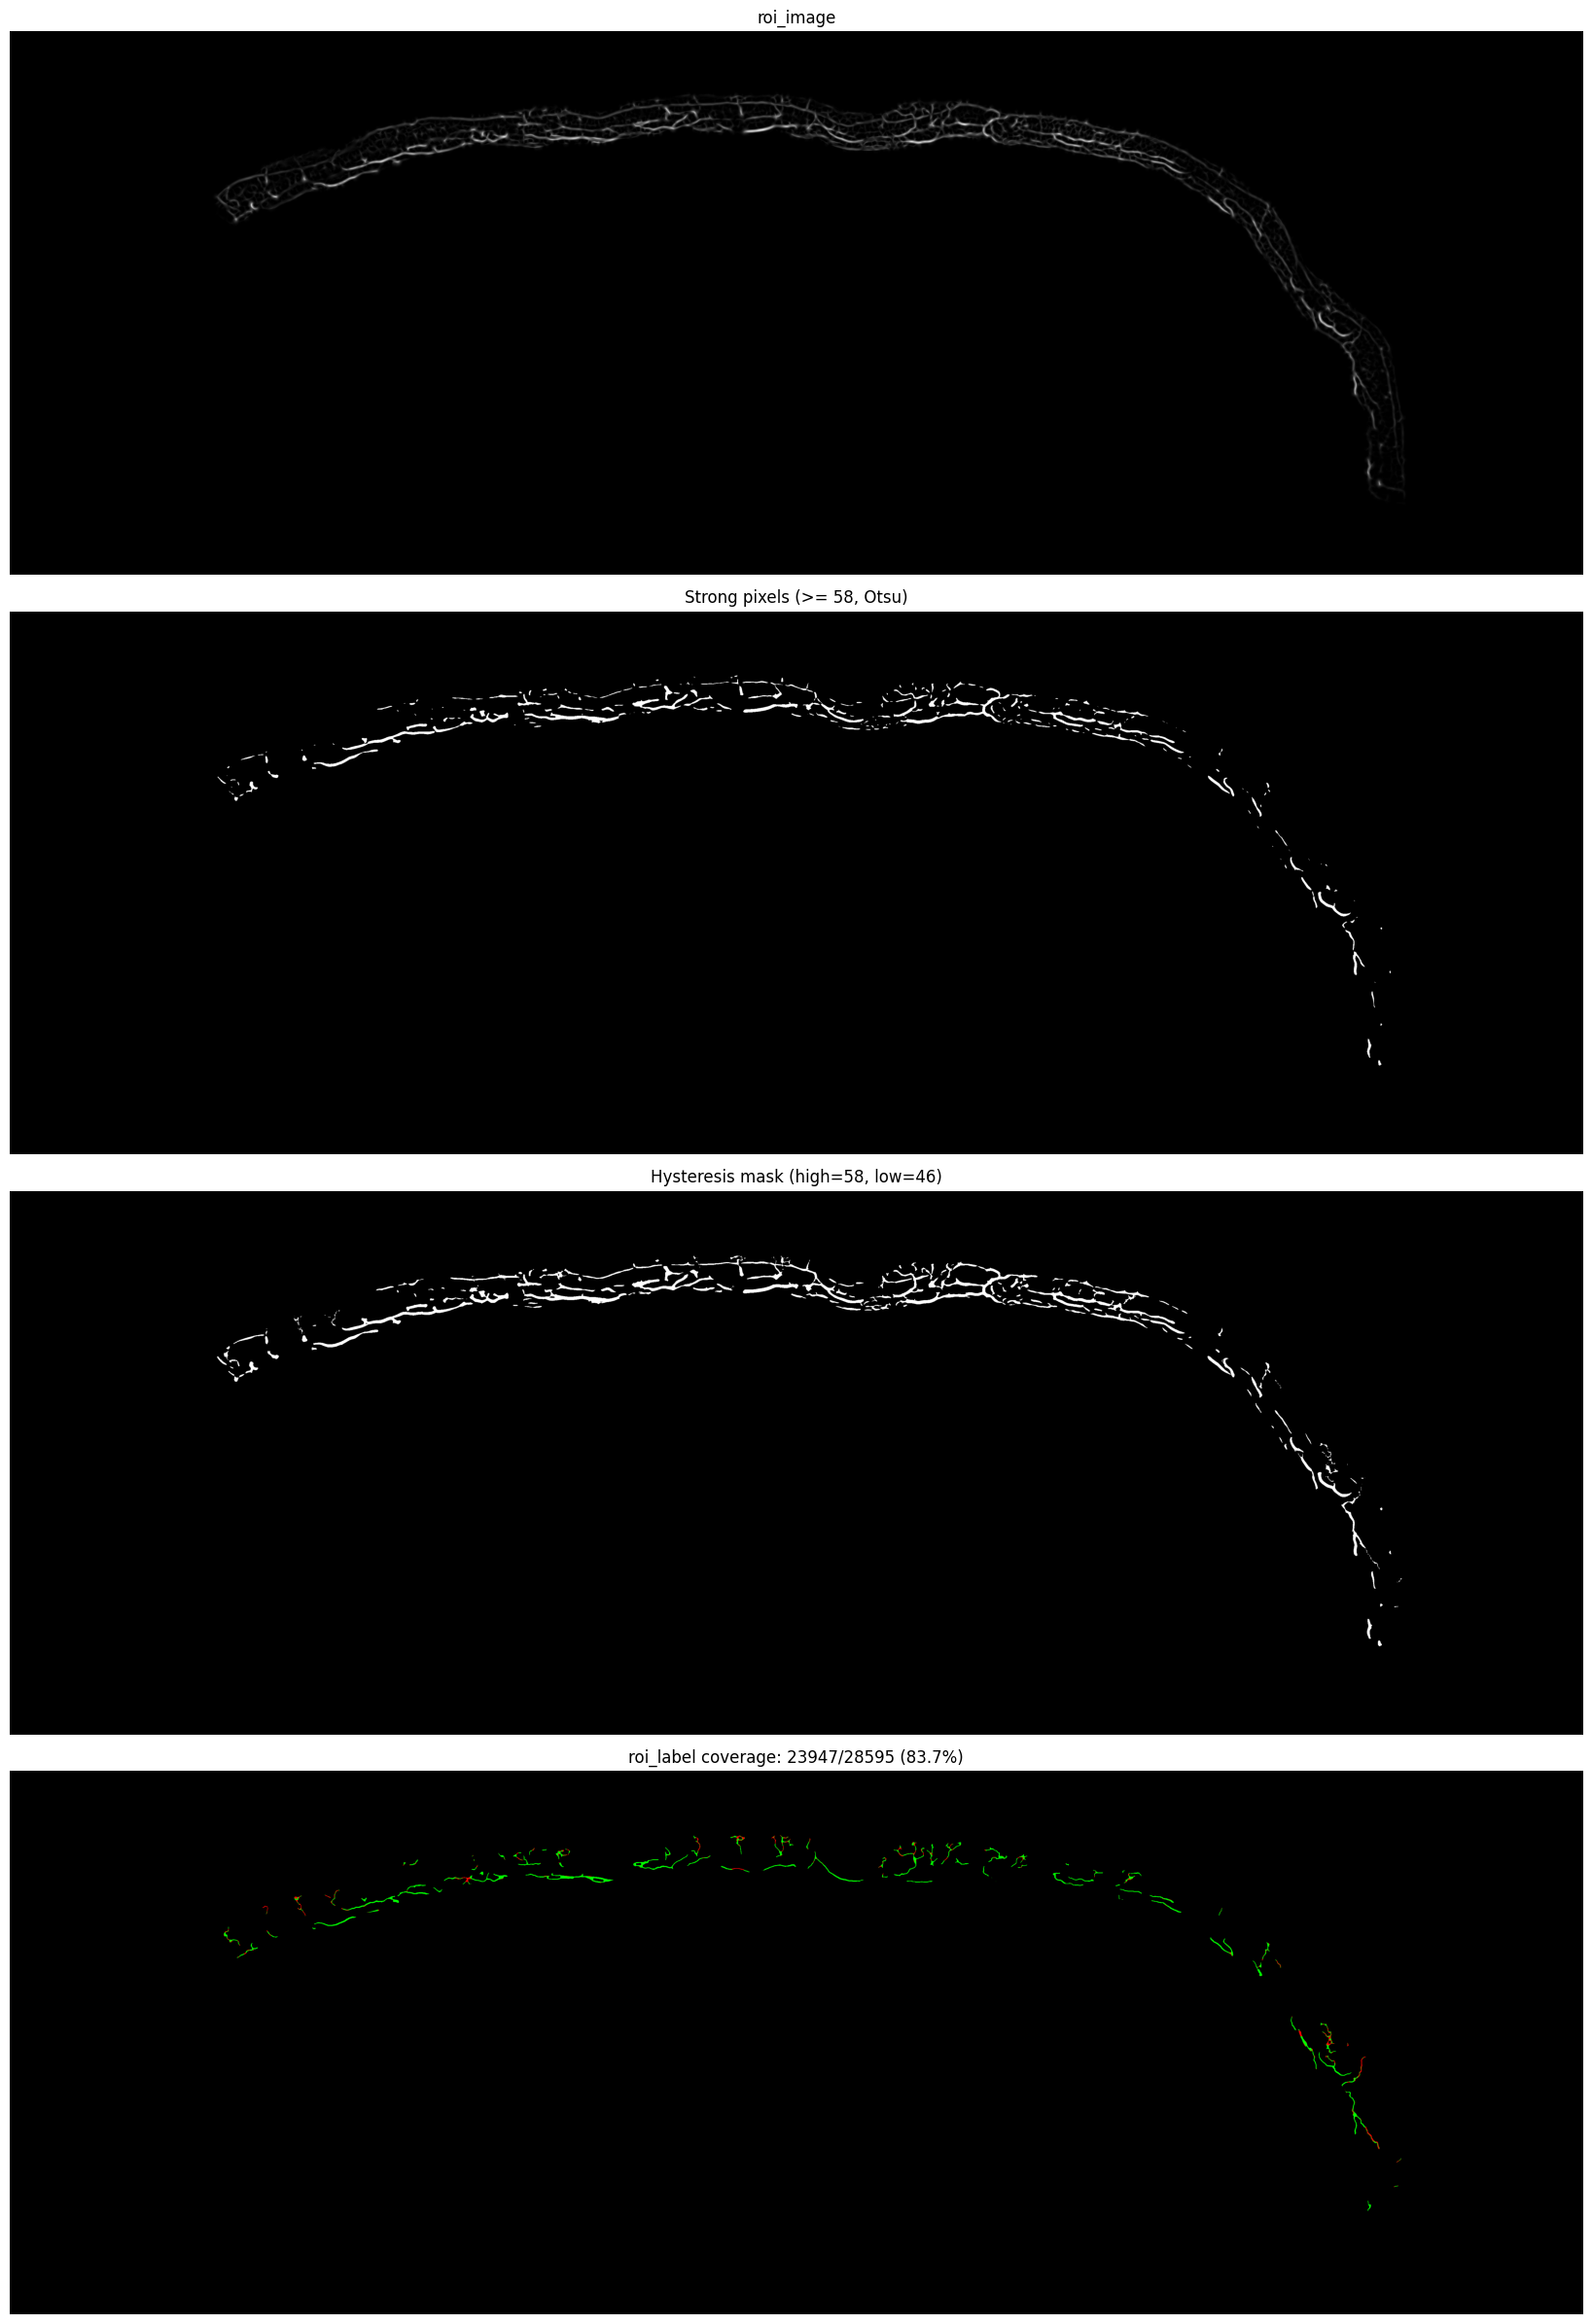

In [98]:
from skimage.morphology import label as sk_label
from sklearn.mixture import GaussianMixture
from skimage.filters import threshold_otsu
from scipy.stats import norm

# --- Hysteresis thresholding (Canny-style) ---
otsu_thresh, _ = cv2.threshold(roi_image[roi_mask > 0], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

high_thresh = min(otsu_thresh * 1.25, 255 * 0.9) 
low_thresh  = otsu_thresh

strong = roi_image >= high_thresh                        # definitely fiber
weak   = (roi_image >= low_thresh) & ~strong             # candidate

# Keep weak pixels only if connected to a strong pixel
combined = strong | weak                                 # union mask
cc_combined = sk_label(combined, connectivity=2)         # label connected regions

# Find which component IDs contain at least one strong pixel
strong_cc_ids = np.unique(cc_combined[strong])
strong_cc_ids = strong_cc_ids[strong_cc_ids != 0]

# Build final mask: all pixels in those components
final_mask = np.isin(cc_combined, strong_cc_ids).astype(np.uint8) * 255
final_mask = cv2.bitwise_or(final_mask, roi_annotation)

print(f"Otsu threshold  : {otsu_thresh:.1f}")
print(f"Low  threshold  : {low_thresh:.1f}")

# --- Pixel-level coverage of roi_label ---
label_pixels    = roi_label > 0
total_label_px  = label_pixels.sum()
covered_px      = np.logical_and(label_pixels, final_mask > 0).sum()
not_covered_px  = total_label_px - covered_px

print(f"\nTotal roi_label pixels   : {total_label_px}")
print(f"Covered by final mask    : {covered_px}")
print(f"Not covered              : {not_covered_px}")
print(f"Pixel coverage rate      : {covered_px / total_label_px * 100:.1f}%")

# --- Visualization ---
fig, axes = plt.subplots(4, 1, figsize=(18, 24))

axes[0].imshow(roi_image, cmap='gray')
axes[0].set_title('roi_image')
axes[0].axis('off')

axes[1].imshow(strong.astype(np.uint8) * 255, cmap='gray')
axes[1].set_title(f'Strong pixels (>= {high_thresh:.0f}, Otsu)')
axes[1].axis('off')

axes[2].imshow(final_mask, cmap='gray')
axes[2].set_title(f'Hysteresis mask (high={high_thresh:.0f}, low={low_thresh:.0f})')
axes[2].axis('off')

overlay = np.zeros((*roi_label.shape, 3), dtype=np.uint8)
overlay[np.logical_and(label_pixels, final_mask > 0)]  = (0, 255, 0)
overlay[np.logical_and(label_pixels, final_mask == 0)] = (255, 0, 0)

axes[3].imshow(overlay)
axes[3].set_title(f'roi_label coverage: {covered_px}/{total_label_px} ({covered_px / total_label_px * 100:.1f}%)')
axes[3].axis('off')

plt.tight_layout()
plt.show()
